In [1]:
!nvidia-smi


Sat Jun 13 20:54:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
from google.colab import userdata
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset

In [3]:

os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['GITHUB_TOKEN'] = userdata.get('GITHUB_TOKEN')
os.environ['GITHUB_USERNAME'] = userdata.get('GITHUB_USERNAME')

print("Secrets loaded successfully")

Secrets loaded successfully


In [4]:
!git clone https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git
%cd ML_hw_04_Facial-Expression-Recognition-Challenge

!pip install -q wandb kaggle


wandb.login(key=os.environ['WANDB_API_KEY'])

print("Setup completed")

Cloning into 'ML_hw_04_Facial-Expression-Recognition-Challenge'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 30 (delta 9), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 83.24 KiB | 5.95 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/ML_hw_04_Facial-Expression-Recognition-Challenge


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kgord23 (kgord23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Setup completed


In [3]:
!kaggle datasets list -s cats

ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset                 Cats-vs-Dogs                                         825979578  2020-03-12 05:34:30.730000         106725        964  0.875            
marquis03/cats-and-dogs                                    Cats and Dogs                                         10219362  2023-10-27 10:48:19.220000          16533        143  1                
waqi786/cats-dataset                                       🐾 Cats Dataset                                            5654  2024-07-31 06:12:49.530000           7030        101  1                
chetankv/dogs-cats-images

In [5]:
!pip install -q -U kaggle
!kaggle --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 11.0 MB/s eta 0:00:00
Kaggle CLI 2.2.1


In [6]:
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(os.environ['KAGGLE_KEY'])

!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p /content/data
!unzip -q /content/data/*.zip -d /content/data
!ls /content/data

100% 285M/285M [00:07<00:00, 39.5MB/s]

challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013.tar.gz
icml_face_data.csv
test.csv
train.csv


In [7]:
for f in os.listdir('/content/data'):
    path = os.path.join('/content/data', f)
    size = os.path.getsize(path) / (1024*1024)
    print(f"{f}: {size:.1f} MB")

example_submission.csv: 0.0 MB
fer2013.tar.gz: 92.0 MB
icml_face_data.csv: 287.1 MB
challenges-in-representation-learning-facial-expression-recognition-challenge.zip: 285.2 MB
test.csv: 57.3 MB
train.csv: 229.5 MB


In [7]:

train_df = pd.read_csv('/content/data/train.csv')
print("Shape:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nFirst row:")
print(train_df.iloc[0])
print("\nEmotion distribution:")
print(train_df['emotion'].value_counts().sort_index())

Shape: (28709, 2)

Columns: ['emotion', 'pixels']

First row:
emotion                                                    0
pixels     70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
Name: 0, dtype: object

Emotion distribution:
emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


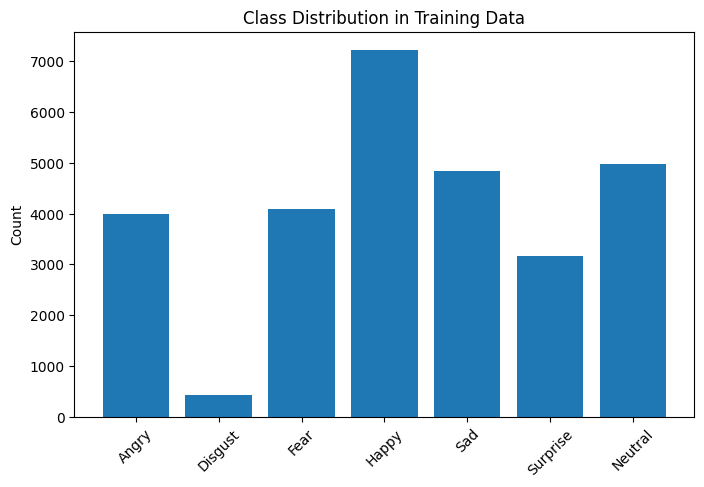

In [9]:

emotion_labels=['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
counts=train_df['emotion'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(emotion_labels, counts.values)
plt.title('Class Distribution in Training Data')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

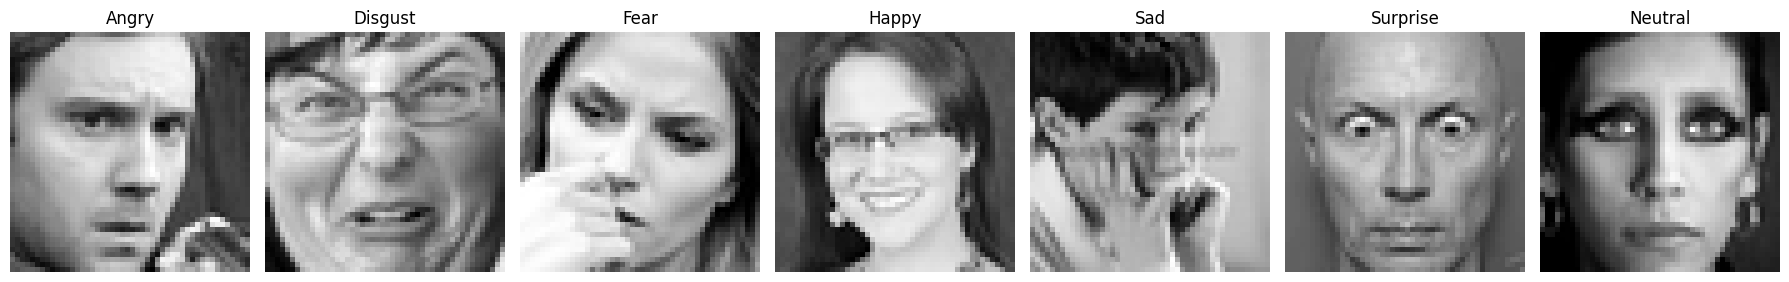

In [10]:

fig, axes = plt.subplots(1, 7, figsize=(18, 3))
for i, emotion in enumerate(emotion_labels):
    sample = train_df[train_df['emotion'] == i].iloc[0]
    pixels = np.array(sample['pixels'].split(), dtype='float32').reshape(48, 48)
    axes[i].imshow(pixels, cmap='gray')
    axes[i].set_title(emotion)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [15]:
train, val=train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['emotion'] )
print("Train: ", train.shape,  "Val: ", val.shape)

Train:  (25838, 2) Val:  (2871, 2)


In [18]:
class FERDataset(Dataset):
  def __init__(self, dataframe, transform=True):
    self.data=dataframe.reset_index(drop=True)
    self.transform=transform
  def __len__(self):
    return len(self.data)
  def __getitem__(self, idx):
    row=self.data.iloc[idx]
    pixels=np.array(row['pixels'].split(), dtype='float32').reshape(48,48)
    image=torch.tensor(pixels, dtype=torch.float32).unsqueeze(0)/255.0
    label=int(row['emotion'])
    if self.transform:
      image=self.transform(image)
    return image, label

In [22]:
train_data = FERDataset(train, transform=None)
val_data = FERDataset(val, transform=None)

img, label = train_data[0]
print("Image shape:", img.shape, "| Label:", label, emotion_labels[label])

Image shape: torch.Size([1, 48, 48]) | Label: 3 Happy


In [11]:
os.makedirs('/content/ML_hw_04_Facial-Expression-Recognition-Challenge/src', exist_ok=True)

In [12]:
%%writefile /content/ML_hw_04_Facial-Expression-Recognition-Challenge/src/dataset.py
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        pixels = np.array(row['pixels'].split(), dtype='float32').reshape(48, 48)
        image = torch.tensor(pixels, dtype=torch.float32).unsqueeze(0) / 255.0
        label = int(row['emotion'])
        if self.transform:
            image = self.transform(image)
        return image, label


def load_data(csv_path='/content/data/train.csv', val_size=0.15, test_size=0.15, random_state=42):
    df = pd.read_csv(csv_path)


    train_val, test = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df['emotion']
    )


    val_ratio = val_size / (1 - test_size)
    train, val = train_test_split(
        train_val, test_size=val_ratio, random_state=random_state, stratify=train_val['emotion']
    )

    return train, val, test

Overwriting /content/ML_hw_04_Facial-Expression-Recognition-Challenge/src/dataset.py


In [14]:
!git config --global user.email "kgord23@freeuni.edu.ge"
!git config --global user.name "kgordeziani"

In [30]:
!git -c core.editor=true pull https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git main --allow-unrelated-histories --no-edit

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.80 KiB | 461.00 KiB/s, done.
From https://github.com/kgordeziani/ML_hw_04_Facial-Expression-Recognition-Challenge
 * branch            main       -> FETCH_HEAD
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: i

In [31]:
!git push https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git main

To https://github.com/kgordeziani/ML_hw_04_Facial-Expression-Recognition-Challenge.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/kgordeziani/ML_hw_04_Facial-Expression-Recognition-Challenge.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [32]:
!git config pull.rebase false
!git -c core.editor=true pull https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git main --allow-unrelated-histories --no-edit

From https://github.com/kgordeziani/ML_hw_04_Facial-Expression-Recognition-Challenge
 * branch            main       -> FETCH_HEAD
Merge made by the 'ort' strategy.
 README.md | 11 ++++++++++-
 1 file changed, 10 insertions(+), 1 deletion(-)


In [33]:
!git push https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git main

Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 1.22 KiB | 1.22 MiB/s, done.
Total 6 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/kgordeziani/ML_hw_04_Facial-Expression-Recognition-Challenge.git
   0843948..a8d9491  main -> main


In [15]:
!git add .
!git commit -m "Update load_data to 3-way split (train/val/test)"
!git push https://{os.environ['GITHUB_TOKEN']}@github.com/{os.environ['GITHUB_USERNAME']}/ML_hw_04_Facial-Expression-Recognition-Challenge.git

[main df7291d] Update load_data to 3-way split (train/val/test)
 1 file changed, 41 insertions(+), 28 deletions(-)
 rewrite src/dataset.py (82%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 677 bytes | 677.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/kgordeziani/ML_hw_04_Facial-Expression-Recognition-Challenge.git
   d8231d5..df7291d  main -> main
